## 市值原始数据与市值因子数据分析

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

capital_dt = pd.read_parquet('data/capital.parquet')
capital_dt=capital_dt.sort_values(by=['stock_code', 'change_date'], ascending=[True, True])
capital_dt.rename(columns={'change_date': 'trade_date'}, inplace=True)
price_dt = pd.read_parquet('data/eod_prices.parquet')
price_dt=price_dt.sort_values(by=['stock_code', 'trade_date'], ascending=[True, True])
mv_factor_dt=pd.merge(price_dt, capital_dt, on=['stock_code', 'trade_date'], how='left')
mv_factor_dt.fillna(method='ffill', inplace=True)
mv_factor_dt.head()
mv_factor_dt['float_a_shares_mv']=mv_factor_dt['float_a_shares']*mv_factor_dt['close_price']
mv_factor_dt['total_a_shares_mv']=mv_factor_dt['total_a_shares']*mv_factor_dt['close_price']
cat_df=pd.read_parquet('data/ref_data/Stock_Industry_Year.parquet')
mv_factor_dt['industry_name'] = mv_factor_dt.assign(year=pd.to_datetime(mv_factor_dt['trade_date'].astype(str)).dt.year).merge(cat_df[['stock_code', 'year', 'industry_name']], on=['stock_code', 'year'], how='left')['industry_name']

mv_factor_dt.dropna(inplace=True)
mv_factor_dt['mv_flt']=-np.log(mv_factor_dt['float_a_shares_mv'])
mv_factor_dt['mv_tot']=-np.log(mv_factor_dt['total_a_shares_mv'])
# 按交易日期分组，对当天全股票池的mv_flt列做Z-score标准化（(值-均值)/标准差）
mv_factor_dt['mv_flt_std'] = mv_factor_dt.groupby('trade_date')['mv_flt'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0  # 避免标准差为0时除以0报错
)

mv_factor_dt['mv_tot_std'] = mv_factor_dt.groupby('trade_date')['mv_tot'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0  # 避免标准差为0时除以0报错
)
mv_factor_dt.head()

,stock_code,trade_date,close_price,adjusted_close,adj_factor,volume,turnover,total_shares,float_shares,total_a_shares,float_a_shares,float_a_shares_mv,total_a_shares_mv,industry_name,mv_flt,mv_tot,mv_flt_std,mv_tot_std
102,000001.SZ,20130614,19.06,423.2233,22.204789,328553.36,6.251254e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.918767e+06,9.765651e+06,银行,-15.593639,-16.094382,-1.744443,-2.218485
103,000001.SZ,20130617,19.24,427.2201,22.204789,309210.22,5.961902e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781,-1.750973,-2.226354
104,000001.SZ,20130618,19.73,438.1005,22.204789,389599.38,7.701559e+05,512437.850182,310502.606910,512363.631057,310533.405247,6.126824e+06,1.010893e+07,银行,-15.628187,-16.128930,-1.774256,-2.250456
105,000001.SZ,20130619,19.24,427.2201,22.204789,369977.53,7.140700e+05,512437.850182,310502.606910,512363.631057,310533.405247,5.974663e+06,9.857876e+06,银行,-15.603038,-16.103781,-1.757097,-2.230350
106,000001.SZ,20130620,11.18,400.6981,35.840616,903066.54,1.029738e+06,819808.237690,496861.283537,819958.402672,496892.496412,5.555258e+06,9.167135e+06,银行,-15.530255,-16.031135,-1.726456,-2.194585


🔍 Full Dataset Negative Value Detection Results
📛 【Abnormal Negative Check】Raw Columns (Must be 0 or positive):
│ close_price          │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ adjusted_close       │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ adj_factor           │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ volume               │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ total_shares         │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ float_shares         │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ total_a_shares       │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ float_a_shares       │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ float_a_shares_mv    │ Negative Count:     0 │ Negative Ratio:   0.00% │
│ total_a_shares_mv    │ Negative Count:     0 │ Negative Ratio:   0.00% │

✅ 【Normal Negative Columns】Log Market Value / Standardized Factors (Allowed):
│ mv_flt          │ Negative Count: 11698036 │ Normal Stati

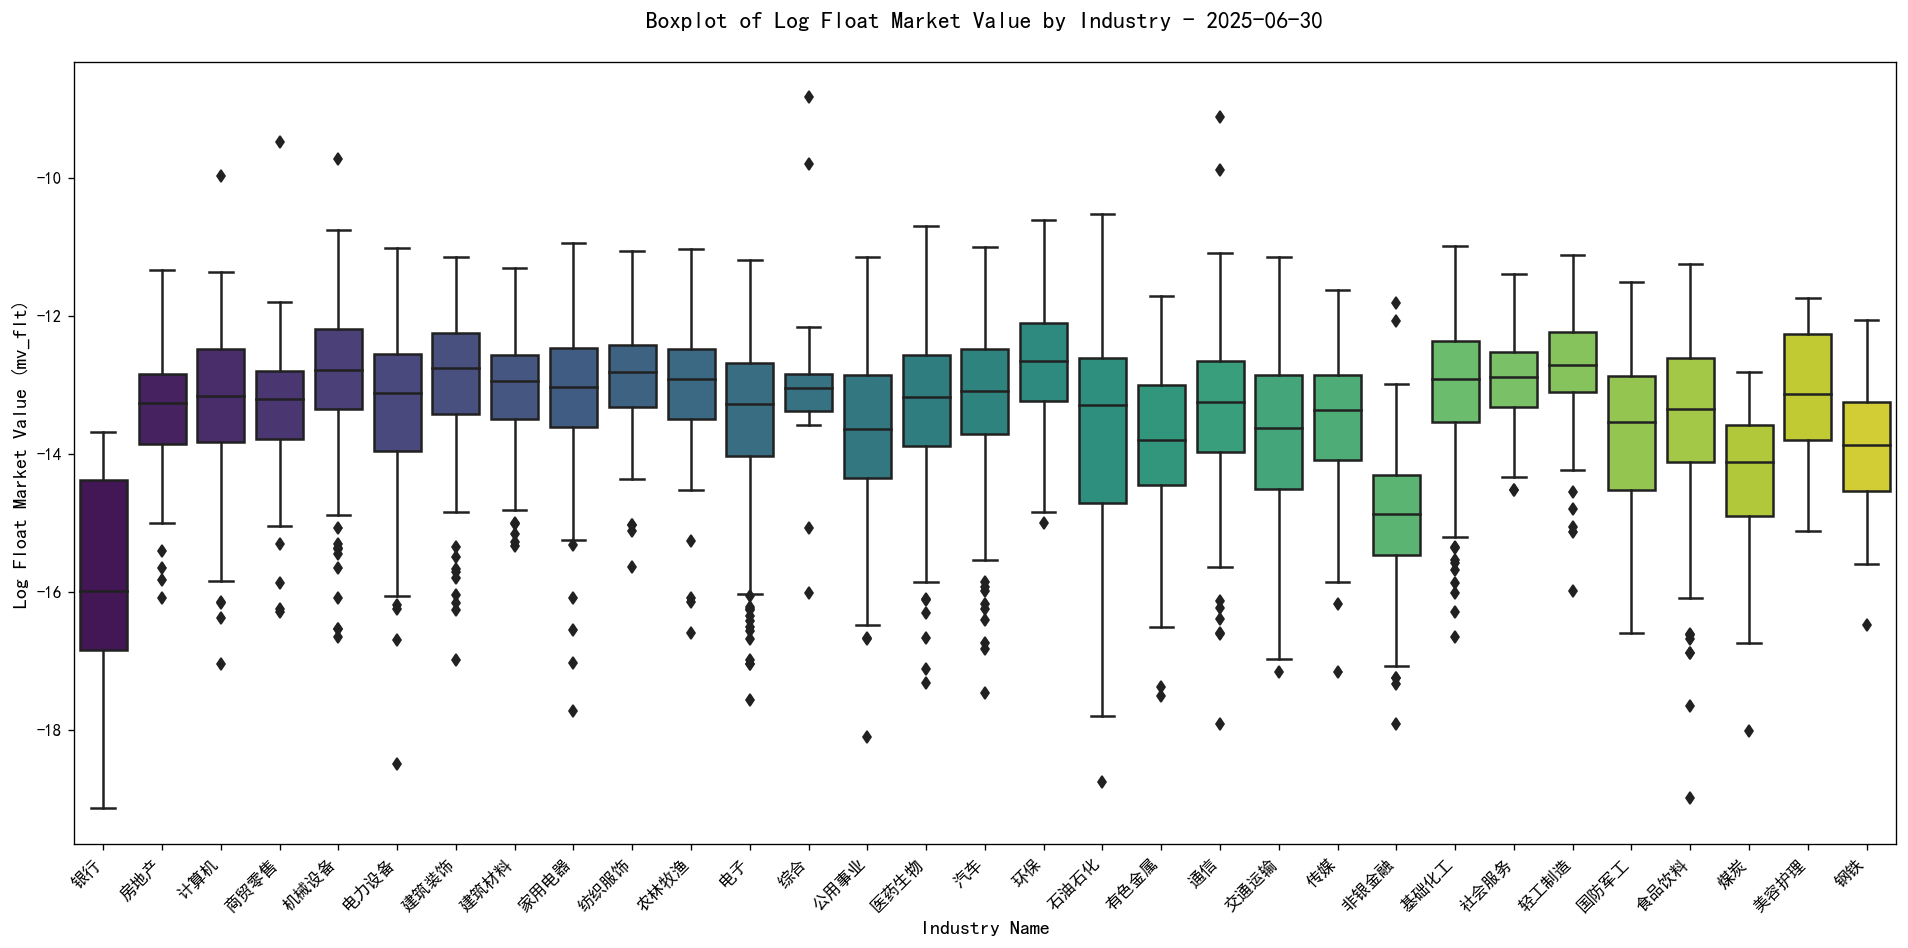

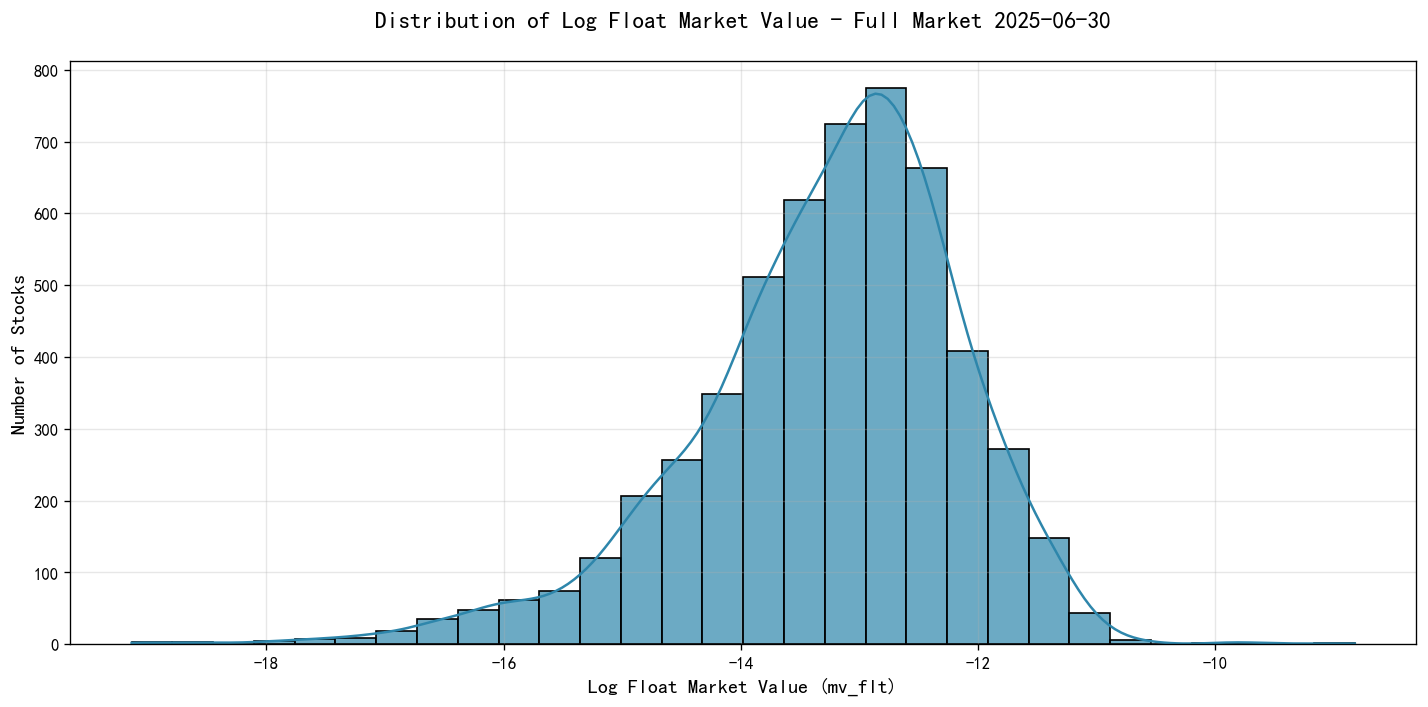

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.rcParams["font.sans-serif"] = ["SimHei"]

# ===================== Basic Settings =====================
# Keep negative sign display & high definition
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['figure.dpi'] = 120

# ===================== 1. Data Preprocessing =====================
df = mv_factor_dt.copy()
# Convert date format (adapt to YYYYMMDD)
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')

# ===================== 2. Full Data Negative Value Check (Core!) =====================
print("="*60)
print("🔍 Full Dataset Negative Value Detection Results")
print("="*60)
# Define core columns to check
# Raw numeric columns (price, shares, volume, etc.): **NO NEGATIVE VALUES ALLOWED**
raw_cols = ['close_price', 'adjusted_close', 'adj_factor', 'volume', 
            'total_shares', 'float_shares', 'total_a_shares', 'float_a_shares',
            'float_a_shares_mv', 'total_a_shares_mv']
# Log/standardized columns: **NEGATIVE VALUES ALLOWED** (normal statistical results)
log_std_cols = ['mv_flt', 'mv_tot', 'mv_flt_std', 'mv_tot_std']

# Check abnormal negative values (raw data)
print("📛 【Abnormal Negative Check】Raw Columns (Must be 0 or positive):")
for col in raw_cols:
    neg_count = (df[col] < 0).sum()
    neg_ratio = (df[col] < 0).mean() * 100
    print(f"│ {col:<20} │ Negative Count: {neg_count:>5} │ Negative Ratio: {neg_ratio:>6.2f}% │")

print("\n✅ 【Normal Negative Columns】Log Market Value / Standardized Factors (Allowed):")
for col in log_std_cols:
    neg_count = (df[col] < 0).sum()
    print(f"│ {col:<15} │ Negative Count: {neg_count:>8} │ Normal Statistical Value │")

# ===================== 3. Extract 2025-06-30 Cross-sectional Data =====================
target_date = pd.to_datetime("20250630", format="%Y%m%d")
section_data = df[df['trade_date'] == target_date].copy()

print("\n" + "="*60)
print(f"📅 2025-06-30 Cross-sectional Data Extracted")
print(f"Total Stocks: {len(section_data)}")
print(f"Total Industries: {section_data['industry_name'].nunique()}")
print("="*60)

# ===================== 4. Boxplot of Market Value by Industry =====================
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=section_data,
    x='industry_name',
    y='mv_flt',
    palette='viridis'
)
plt.title('Boxplot of Log Float Market Value by Industry - 2025-06-30', fontsize=14, pad=20)
plt.xlabel('Industry Name', fontsize=12)
plt.ylabel('Log Float Market Value (mv_flt)', fontsize=12)
# Rotate industry names to avoid overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ===================== 5. Histogram & Density Curve of Full Market Value =====================
plt.figure(figsize=(12, 6))
# Histogram + Kernel Density Estimation
sns.histplot(
    data=section_data,
    x='mv_flt',
    bins=30,
    kde=True,
    color='#2E86AB',
    alpha=0.7
)
plt.title('Distribution of Log Float Market Value - Full Market 2025-06-30', fontsize=14, pad=20)
plt.xlabel('Log Float Market Value (mv_flt)', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
#以20250630为例，原始mv_flt的Q3和Q1值
temp=mv_factor_dt[(mv_factor_dt['trade_date']=='20250630')]
print("Q3:",round(temp['float_a_shares_mv'].quantile(0.75)/10000,2), "亿")
print("Q1:", round(temp['float_a_shares_mv'].quantile(0.25)/10000,2), "亿")


Q3: 106.38 亿
Q1: 27.11 亿


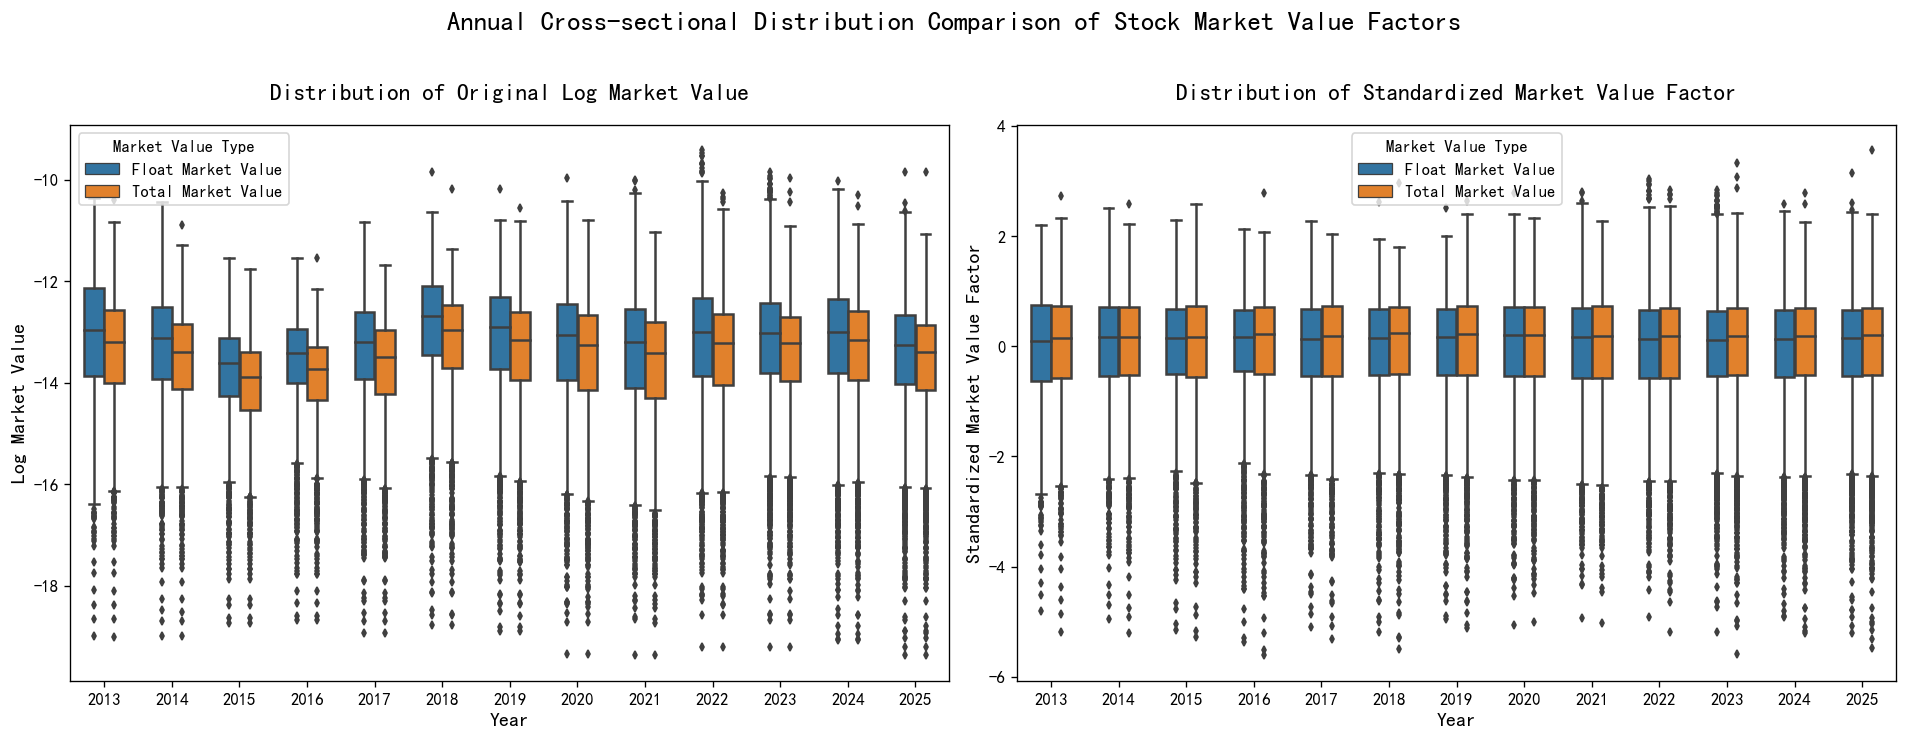

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# 屏蔽所有字体查找失败的警告
warnings.filterwarnings('ignore', category=UserWarning, message="findfont:")
warnings.filterwarnings('ignore', category=FutureWarning)
# 英文环境
plt.rcParams["axes.unicode_minus"] = False  # 保留负号正常显示
plt.rcParams['figure.dpi'] = 120  # 高清画图

# 2. 数据预处理（直接使用mv_factor_dt）
df = mv_factor_dt.copy()
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df['year'] = df['trade_date'].dt.year

# 3. 每年取最后一个交易日作为截面（行业标准做法）
year_end_date = df.groupby('year')['trade_date'].max().reset_index()
yearly_data = pd.merge(df, year_end_date, on=['year', 'trade_date'], how='inner')

# ==============================================
# 4. 数据预处理：重命名变量，自动生成正确图例
# ==============================================
# 处理原始对数市值数据
df_melt_raw = yearly_data.melt(
    id_vars='year',
    value_vars=['mv_flt', 'mv_tot'],
    var_name='Market Value Type',
    value_name='Log Market Value'
)
#
df_melt_raw['Market Value Type'] = df_melt_raw['Market Value Type'].replace({
    'mv_flt': 'Float Market Value',
    'mv_tot': 'Total Market Value'
})

# 处理标准化后数据
df_melt_std = yearly_data.melt(
    id_vars='year',
    value_vars=['mv_flt_std', 'mv_tot_std'],
    var_name='Market Value Type',
    value_name='Standardized Market Value Factor'
)
df_melt_std['Market Value Type'] = df_melt_std['Market Value Type'].replace({
    'mv_flt_std': 'Float Market Value',
    'mv_tot_std': 'Total Market Value'
})

# ==============================================
# 5. 箱线图可视化
# ==============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Annual Cross-sectional Distribution Comparison of Stock Market Value Factors', 
             fontsize=16, fontweight='bold', y=1.02)

# 子图1：原始对数市值分布
sns.boxplot(
    x='year',
    y='Log Market Value',
    hue='Market Value Type',
    data=df_melt_raw,
    ax=ax1,
    palette=['#1f77b4', '#ff7f0e'],
    width=0.6,
    fliersize=3
)
ax1.set_title('Distribution of Original Log Market Value', fontsize=14, pad=15)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Log Market Value', fontsize=12)
ax1.legend(title='Market Value Type', frameon=True)

# 子图2：标准化后市值因子分布
sns.boxplot(
    x='year',
    y='Standardized Market Value Factor',
    hue='Market Value Type',
    data=df_melt_std,
    ax=ax2,
    palette=['#1f77b4', '#ff7f0e'],
    width=0.6,
    fliersize=3
)
ax2.set_title('Distribution of Standardized Market Value Factor', fontsize=14, pad=15)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Standardized Market Value Factor', fontsize=12)
ax2.legend(title='Market Value Type', frameon=True)

plt.tight_layout()
plt.show()

## IQR=Q3-Q1 Outlier Spots: Q1-1.5×IQR,Q3+1.5×IQR

In [27]:
import pandas as pd
from warnings import filterwarnings
from tqdm import tqdm
from util import *

filterwarnings('ignore')


PRICE_FILE = 'data/eod_prices.parquet'
DIVIDEND_FILE = 'data/dividend.parquet'
FUND_FILE = 'data/ref_data/ETF_hold_510300.SH.parquet'   # CSI300 ETF持仓数据
INDUSTRY_FILE = 'data/ref_data/Stock_Industry_Year.parquet'

# ----------------------------
# 1. 数据预处理 & 股票池过滤 (锁定沪深300)
# ----------------------------
print("Loading base data & extracting CSI 300 universe...")
dividend = pd.read_parquet(DIVIDEND_FILE)
price_dt = pd.read_parquet(PRICE_FILE)
fund_df = pd.read_parquet(FUND_FILE)
industry_df = pd.read_parquet(INDUSTRY_FILE)

# 统一日期格式
dividend['announce_date'] = pd.to_datetime(dividend['announce_date'])
dividend['ex_date'] = pd.to_datetime(dividend['ex_date'])
price_dt['trade_date'] = pd.to_datetime(price_dt['trade_date'])

# 处理ETF持仓日期逻辑
fund_df = fund_df.rename(columns={'end_date': 'report_end_date'}) 
fund_df['report_end_date'] = pd.to_datetime(fund_df['report_end_date'])

def get_position_valid_period(row):
    year = row['report_year']
    if row['report_type'] == '中报':
        start_date = pd.to_datetime(f'{year}-01-01')
        end_date = pd.to_datetime(f'{year}-06-30')
    elif row['report_type'] == '年报':
        start_date = pd.to_datetime(f'{year}-07-01')
        end_date = pd.to_datetime(f'{year}-12-31')
    else:
        start_date = end_date = row['report_end_date']
    return pd.Series([start_date, end_date], index=['pos_start_date', 'pos_end_date'])

fund_df[['pos_start_date', 'pos_end_date']] = fund_df.apply(get_position_valid_period, axis=1)
fund_holdings = fund_df[['stock_code', 'pos_start_date', 'pos_end_date']].drop_duplicates()

# 针对CSI300历史持仓股过滤
csi_300_stocks = fund_holdings['stock_code'].unique()
print(f"Total historical stocks in CSI 300 universe: {len(csi_300_stocks)}")

price_dt_subset = price_dt[price_dt['stock_code'].isin(csi_300_stocks)].sort_values(['stock_code', 'trade_date'])
dividend_subset = dividend[dividend['stock_code'].isin(csi_300_stocks)].sort_values(['stock_code', 'announce_date'])

# ----------------------------
# 2. 因子计算
# ----------------------------
print("Calculating dividend factors for CSI 300 stocks...")
df_factors_list = []
total_stocks = price_dt_subset['stock_code'].nunique()

for stock, price_sub in tqdm(price_dt_subset.groupby('stock_code'), total=total_stocks, desc="Processing stocks"):
    if stock in dividend_subset['stock_code'].values:
        div_sub = dividend_subset[dividend_subset['stock_code'] == stock]
        factor_sub = calc_factors(price_sub, div_sub) 
        df_factors_list.append(factor_sub)
    else:
        temp_df = price_sub[['stock_code', 'trade_date']].copy()
        temp_df['expected_div_yield'] = 0.0
        temp_df['static_div_yield'] = 0.0
        temp_df['dynamic_div_yield'] = 0.0
        df_factors_list.append(temp_df)

div_factor_dt = pd.concat(df_factors_list, ignore_index=True)

# 合并行业信息 (通过年度关联)
print("Merging industry info to factor table...")
div_factor_dt['year'] = div_factor_dt['trade_date'].dt.year
industry_df['year'] = industry_df['year'].astype(int)
div_factor_dt = div_factor_dt.merge(industry_df[['stock_code', 'year', 'industry_name']], 
                                    on=['stock_code', 'year'], 
                                    how='left')
div_factor_dt.head()

Loading base data & extracting CSI 300 universe...
Total historical stocks in CSI 300 universe: 584
Calculating dividend factors for CSI 300 stocks...


Processing stocks: 5693it [35:33,  2.67it/s]                        


Merging industry info to factor table...


,stock_code,trade_date,expected_div_yield,static_div_yield,dynamic_div_yield,year,industry_name
0,000001.SZ,2013-01-04,0.0,0.0,0.0,2013,银行
1,000001.SZ,2013-01-07,0.0,0.0,0.0,2013,银行
2,000001.SZ,2013-01-08,0.0,0.0,0.0,2013,银行
3,000001.SZ,2013-01-09,0.0,0.0,0.0,2013,银行
4,000001.SZ,2013-01-10,0.0,0.0,0.0,2013,银行


In [ ]:
div_factor_dt.to_parquet('data/dividend_factor.parquet', index=False)

🔍 股息率因子负值检测结果
✅ 【标准化列】股息率标准化值（允许负值）：
│ expected_div_yield_std    │ 负值数量: 1019380 │ 负值占比:  63.48% │
│ dynamic_div_yield_std     │ 负值数量: 1018896 │ 负值占比:  63.45% │

📊 标准化股息率描述性统计
       expected_div_yield_std  dynamic_div_yield_std
count            1.605861e+06           1.605861e+06
mean            -2.973388e-18           1.180506e-17
std              9.946941e-01           9.941505e-01
min             -1.070991e+00          -1.071922e+00
25%             -6.982146e-01          -6.963192e-01
50%             -2.923444e-01          -2.910750e-01
75%              3.236651e-01           3.207254e-01
max              2.080871e+01           2.080871e+01


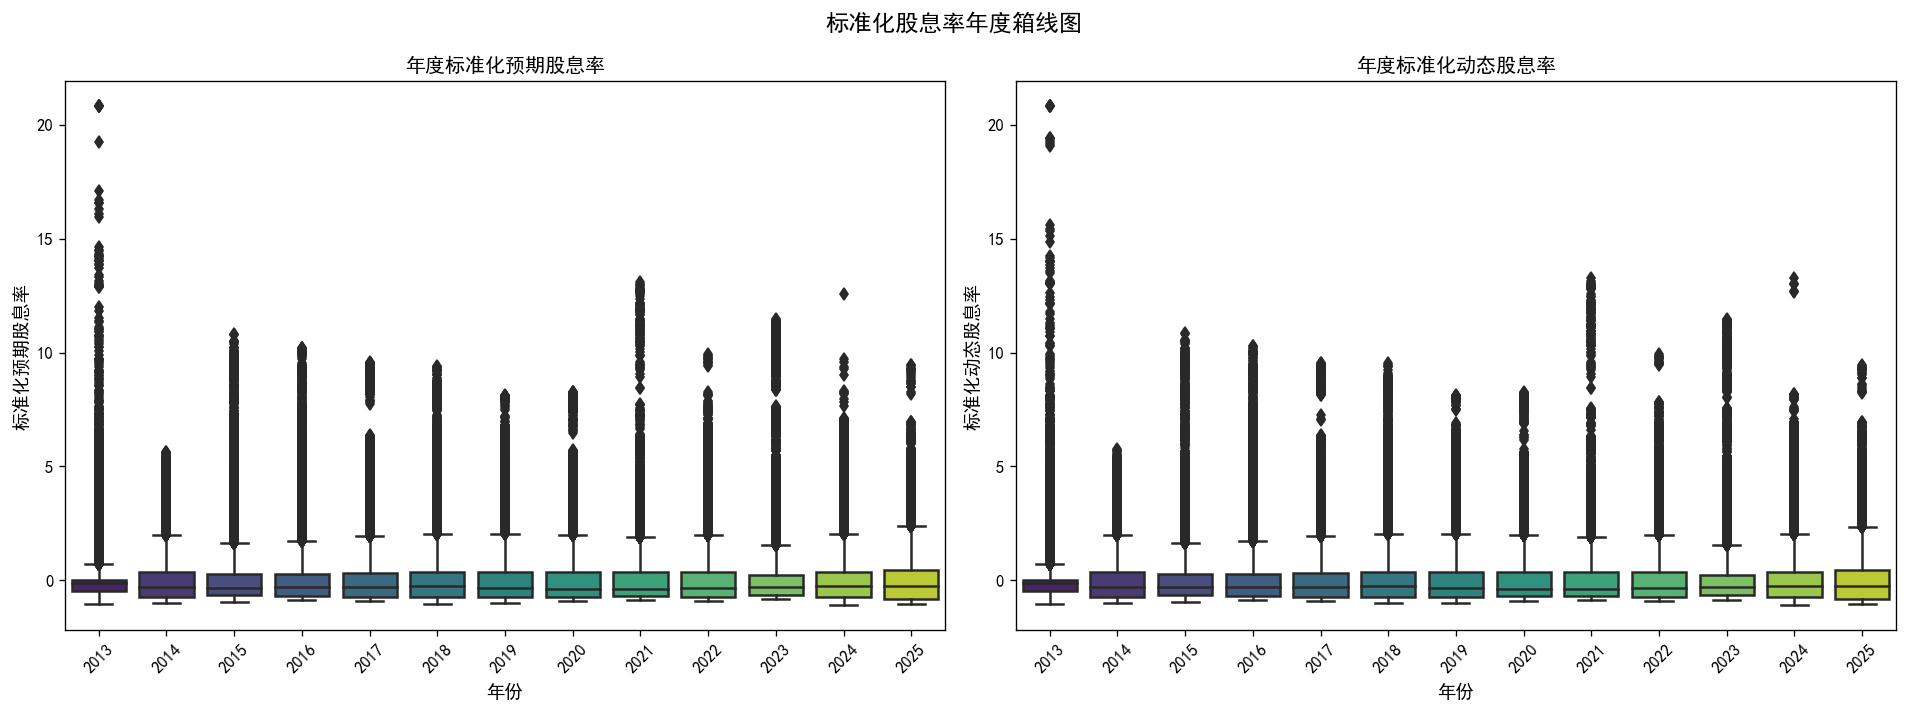


📅 2025-06-30 截面数据提取
股票数量: 567
行业数量: 31

📈 2025-06-30 原始股息率分位数（90%/75%/25%）
│ expected_div_yield   │ 25%分位: 0.0028 │ 75%分位: 0.0307 │ 99%分位: 0.1047 │
│ dynamic_div_yield    │ 25%分位: 0.0031 │ 75%分位: 0.0312 │ 99%分位: 0.0981 │


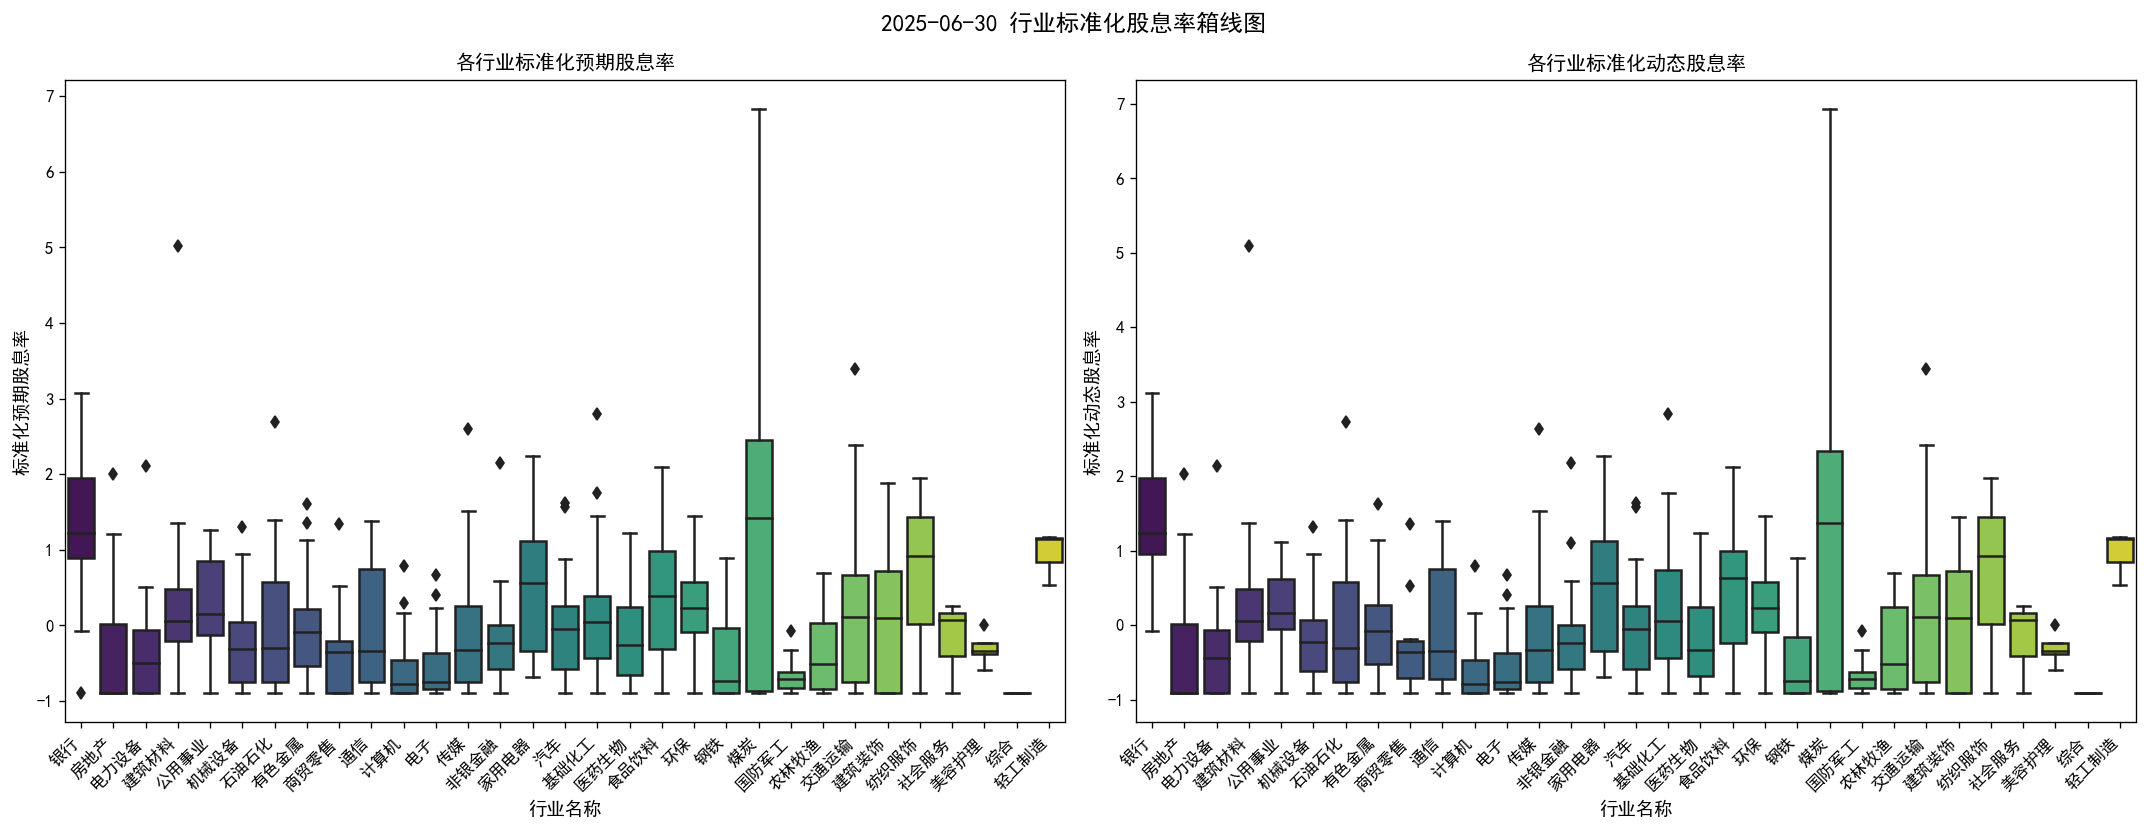

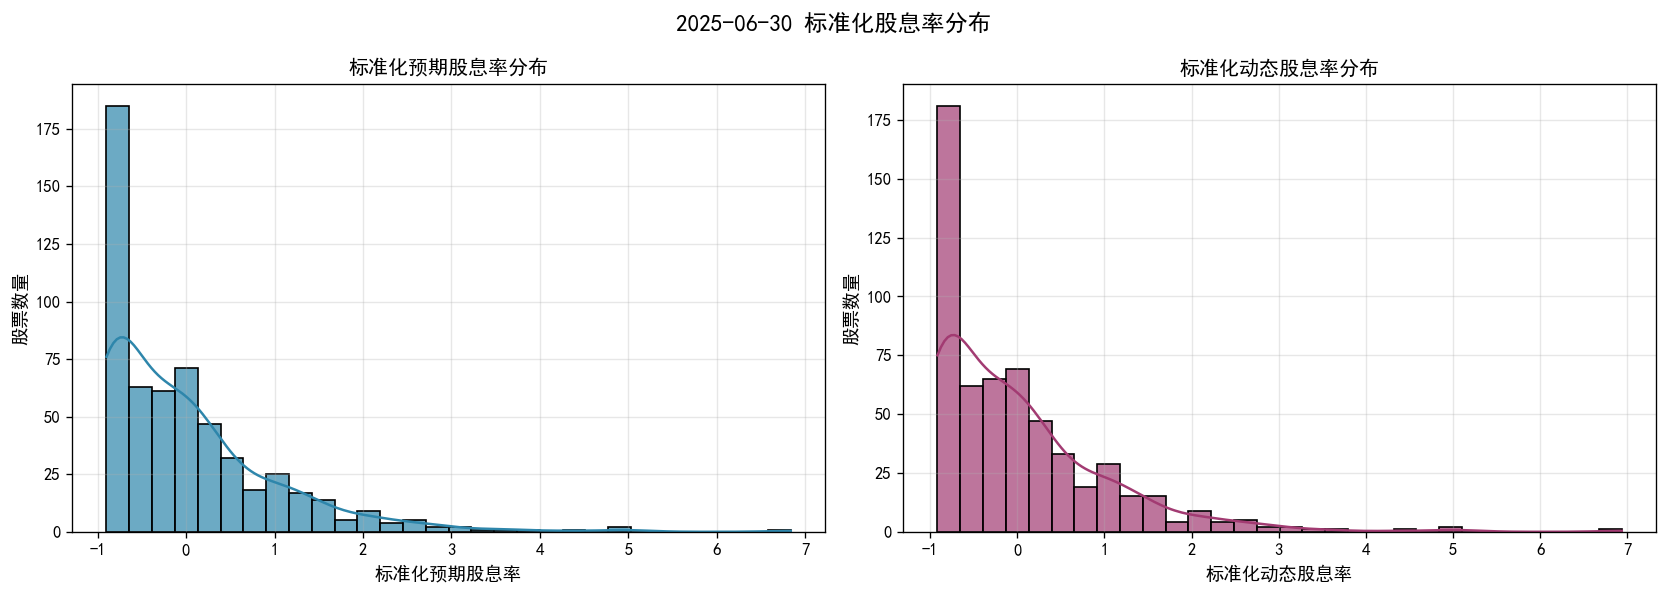

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 全局字体、绘图配置
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['figure.dpi'] = 120

# ===================== 1. 数据加载 + 标准化计算（仅执行1次） =====================
div_factor_dt = pd.read_parquet('data/dividend_factor.parquet')
# 日期格式转换
div_factor_dt["trade_date"] = pd.to_datetime(div_factor_dt["trade_date"])
div_factor_dt["year"] = div_factor_dt["trade_date"].dt.year

# 【核心】按交易日分组标准化股息率（去均值/除标准差）
div_factor_dt['expected_div_yield_std'] = div_factor_dt.groupby('trade_date')['expected_div_yield'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
)
div_factor_dt['dynamic_div_yield_std'] = div_factor_dt.groupby('trade_date')['dynamic_div_yield'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
)

# ===================== 2. 负值检测（标准化列允许负值，修正提示） =====================
print("="*60)
print("🔍 股息率因子负值检测结果")
print("="*60)
# 标准化列：允许负值（统计标准化结果）
div_cols_std = ["expected_div_yield_std", "dynamic_div_yield_std"]

print("✅ 【标准化列】股息率标准化值（允许负值）：")
for col in div_cols_std:
    neg_count = (div_factor_dt[col] < 0).sum()
    neg_ratio = (div_factor_dt[col] < 0).mean() * 100
    print(f"│ {col:<25} │ 负值数量: {neg_count:>6} │ 负值占比: {neg_ratio:>6.2f}% │")

# ===================== 3. 描述性统计 =====================
print("\n" + "="*60)
print("📊 标准化股息率描述性统计")
print("="*60)
desc_stats = div_factor_dt[div_cols_std].describe()
print(desc_stats)

# ===================== 4. 【标准化】年度股息率箱线图 =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左图：标准化预期股息率
sns.boxplot(
    data=div_factor_dt,
    x='year',
    y='expected_div_yield_std',  # 替换为标准化列
    palette='viridis',
    ax=ax1
)
ax1.set_title('年度标准化预期股息率', fontsize=12)
ax1.set_xlabel('年份', fontsize=11)
ax1.set_ylabel('标准化预期股息率', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# 右图：标准化动态股息率
sns.boxplot(
    data=div_factor_dt,
    x='year',
    y='dynamic_div_yield_std',  # 替换为标准化列
    palette='viridis',
    ax=ax2
)
ax2.set_title('年度标准化动态股息率', fontsize=12)
ax2.set_xlabel('年份', fontsize=11)
ax2.set_ylabel('标准化动态股息率', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('标准化股息率年度箱线图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== 5. 提取2025-06-30截面数据 =====================
target_date = pd.to_datetime("2025-06-30")
df_20250630 = div_factor_dt[div_factor_dt["trade_date"] == target_date].copy()

print("\n" + "="*60)
print(f"📅 2025-06-30 截面数据提取")
if df_20250630.empty:
    print(f"⚠️ 警告：未找到 {target_date.date()} 数据！")
else:
    print(f"股票数量: {len(df_20250630)}")
    print(f"行业数量: {df_20250630['industry_name'].nunique()}")
print("="*60)

# ===================== 【新增】2025-06-30 原始股息率分位数打印 =====================
if not df_20250630.empty:
    print("\n" + "="*60)
    print("📈 2025-06-30 原始股息率分位数（90%/75%/25%）")
    print("="*60)
    # 计算分位数
    quantiles = [0.25, 0.75, 0.99]
    original_div = df_20250630[["expected_div_yield", "dynamic_div_yield"]].quantile(quantiles)
    # 格式化打印
    for col in ["expected_div_yield", "dynamic_div_yield"]:
        q25 = original_div.loc[0.25, col]
        q75 = original_div.loc[0.75, col]
        q99 = original_div.loc[0.99, col]
        print(f"│ {col:<20} │ 25%分位: {q25:>6.4f} │ 75%分位: {q75:>6.4f} │ 99%分位: {q99:>6.4f} │")

# ===================== 6. 【标准化】行业股息率箱线图 =====================
if not df_20250630.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # 左图：行业标准化预期股息率
    sns.boxplot(
        data=df_20250630,
        x='industry_name',
        y='expected_div_yield_std',  # 替换为标准化列
        palette='viridis',
        ax=ax1
    )
    ax1.set_title('各行业标准化预期股息率', fontsize=12)
    ax1.set_xlabel('行业名称', fontsize=11)
    ax1.set_ylabel('标准化预期股息率', fontsize=11)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

    # 右图：行业标准化动态股息率
    sns.boxplot(
        data=df_20250630,
        x='industry_name',
        y='dynamic_div_yield_std',  # 替换为标准化列
        palette='viridis',
        ax=ax2
    )
    ax2.set_title('各行业标准化动态股息率', fontsize=12)
    ax2.set_xlabel('行业名称', fontsize=11)
    ax2.set_ylabel('标准化动态股息率', fontsize=11)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

    plt.suptitle('2025-06-30 行业标准化股息率箱线图', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ===================== 7. 【标准化】股息率分布直方图 =====================
if not df_20250630.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 左图：标准化预期股息率分布
    sns.histplot(
        data=df_20250630,
        x='expected_div_yield_std',  # 替换为标准化列
        bins=30,
        kde=True,
        color='#2E86AB',
        alpha=0.7,
        ax=ax1
    )
    ax1.set_title('标准化预期股息率分布', fontsize=12)
    ax1.set_xlabel('标准化预期股息率', fontsize=11)
    ax1.set_ylabel('股票数量', fontsize=11)
    ax1.grid(alpha=0.3)

    # 右图：标准化动态股息率分布
    sns.histplot(
        data=df_20250630,
        x='dynamic_div_yield_std',  # 替换为标准化列
        bins=30,
        kde=True,
        color='#A23B72',
        alpha=0.7,
        ax=ax2
    )
    ax2.set_title('标准化动态股息率分布', fontsize=12)
    ax2.set_xlabel('标准化动态股息率', fontsize=11)
    ax2.set_ylabel('股票数量', fontsize=11)
    ax2.grid(alpha=0.3)

    plt.suptitle('2025-06-30 标准化股息率分布', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()